# Modèles de référence basés sur le lag

## Introduction

Ce notebook présente une série de modèles de référence (baselines) fondés sur différents décalages temporels — Lag-1, Lag-24 et Lag-168 — afin d’évaluer la capacité prédictive des valeurs passées du trafic cycliste. L’objectif est d’établir un point de comparaison pour mesurer l’apport des futurs modèles plus avancés.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/processed/df_processed.csv', sep=',')

In [3]:
df.head()

,Nom du compteur,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Lien vers photo du site de comptage,Direction,Latitude,Longitude,Température (°C),Précipitations (mm),...,Mois,Année,Heure,Jour de la semaine,Week-end,Vacances,lag_1h,lag_24h,lag_168h,roll_mean_3h
0,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,0,2025-01-07 11:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,4.3,1.8,...,1,2025,11,1,0,0,NaN,NaN,NaN,NaN
1,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,13,2025-01-07 12:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,5.4,0.0,...,1,2025,12,1,0,0,0.0,NaN,NaN,NaN
2,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,50,2025-01-07 13:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.3,0.0,...,1,2025,13,1,0,0,13.0,NaN,NaN,NaN
3,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,54,2025-01-07 14:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.8,0.5,...,1,2025,14,1,0,0,50.0,NaN,NaN,21.0
4,10 avenue de la Grande Armée 10 avenue de la G...,10 avenue de la Grande Armée,33,2025-01-07 15:00:00,https://filer.eco-counter-tools.com/file/26/1d...,Bike IN,48.8748,2.2924,6.9,0.0,...,1,2025,15,1,0,0,54.0,NaN,NaN,39.0


## Lag-1h

Ce modèle prédit le comptage horaire d’un compteur à l’instant t en utilisant directement la valeur observée à l’instant t – 1. Autrement dit, il suppose que le trafic à une heure donnée sera le même que celui de l’heure précédente.

In [4]:
df_model1 = df.sort_values(['Nom du compteur', 'Date et heure de comptage']).reset_index(drop=True)
df_model1 = df_model1.dropna(subset=['lag_1h'])

y_true = df_model1['Comptage horaire']
y_pred = df_model1['lag_1h']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 29.36
RMSE : 58.96
R²   : 0.704


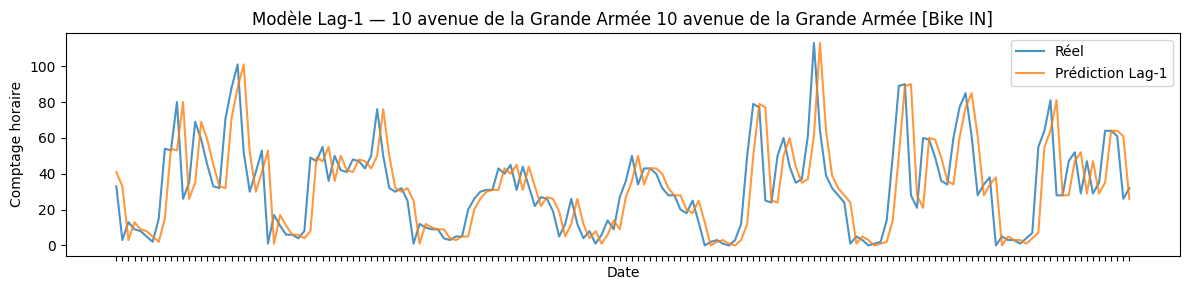

In [5]:
site = df_model1['Nom du compteur'].unique()[0]
df_model1_plot = df_model1[df_model1['Nom du compteur'] == site].tail(168)  # Affiche les 7 derniers jours

plt.figure(figsize=(12, 3))
plt.plot(
    df_model1_plot['Date et heure de comptage'],
    df_model1_plot['Comptage horaire'],
    label="Réel",
    alpha=0.8
)
plt.plot(
    df_model1_plot['Date et heure de comptage'],
    df_model1_plot['lag_1h'],
    label="Prédiction Lag-1",
    alpha=0.8
)
plt.title(f"Modèle Lag-1 — {site}")
plt.xlabel("Date")
plt.tick_params(
    axis='x',
    which='both',
    labelbottom=False
)
plt.ylabel("Comptage horaire")
plt.tight_layout()
plt.legend()
plt.show()

## Lag-24h

Ce modèle prédit le comptage horaire à l’instant t en utilisant la valeur observée à t – 24 heures.

Il repose sur l’idée que les flux de vélos suivent une saisonnalité journalière : le trafic à une heure donnée aujourd’hui est souvent similaire à celui observé la veille à la même heure. Ce modèle sert de référence pour capturer ces variations quotidiennes simples.

In [6]:
df_model24 = df.sort_values(['Nom du compteur', 'Date et heure de comptage']).reset_index(drop=True)
df_model24 = df_model24.dropna(subset=['lag_24h'])

y_true = df_model24['Comptage horaire']
y_pred = df_model24['lag_24h']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 25.75
RMSE : 54.12
R²   : 0.751


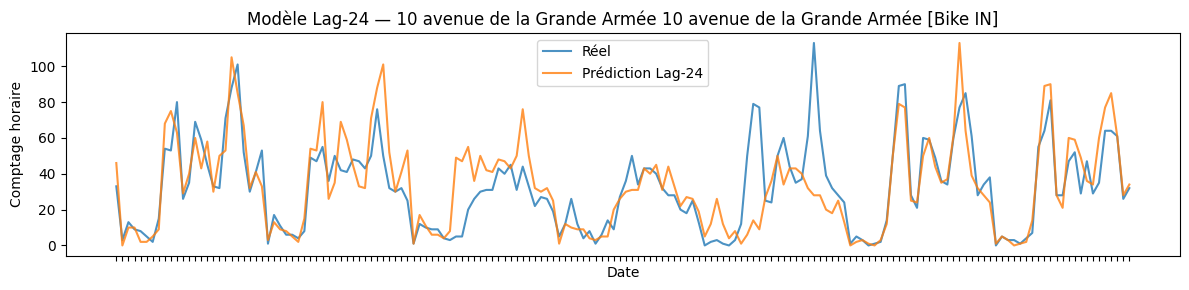

In [7]:
site = df_model24['Nom du compteur'].unique()[0]
df_model24_plot = df_model24[df_model24['Nom du compteur'] == site].tail(168)  # Affiche les 7 derniers jours

plt.figure(figsize=(12, 3))
plt.plot(
    df_model24_plot['Date et heure de comptage'],
    df_model24_plot['Comptage horaire'],
    label="Réel",
    alpha=0.8
)
plt.plot(
    df_model24_plot['Date et heure de comptage'],
    df_model24_plot['lag_24h'],
    label="Prédiction Lag-24",
    alpha=0.8
)
plt.title(f"Modèle Lag-24 — {site}")
plt.xlabel("Date")
plt.tick_params(
    axis='x',
    which='both',
    labelbottom=False
)
plt.ylabel("Comptage horaire")
plt.tight_layout()
plt.legend()
plt.show()

## Lag-24h*7

Ce modèle prédit le comptage horaire à l’instant t en utilisant la valeur observée à t – 7 jours.

Il repose sur l’hypothèse que les flux de vélos suivent une saisonnalité hebdomadaire stable (par exemple, le trafic à 8h un lundi ressemble au trafic du lundi précédent à 8h). Ce modèle permet de capturer les régularités saisonnières simples et sert de troisième référence avant de tester des modèles plus avancés.

In [8]:
df_model168 = df.sort_values(['Nom du compteur', 'Date et heure de comptage']).reset_index(drop=True)
df_model168 = df_model168.dropna(subset=['lag_168h'])

y_true = df_model168['Comptage horaire']
y_pred = df_model168['lag_168h']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 24.02
RMSE : 50.73
R²   : 0.782


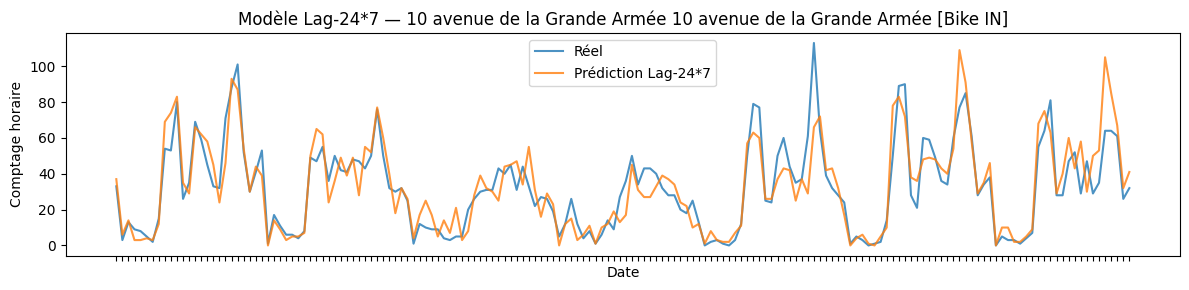

In [9]:
site = df_model168['Nom du compteur'].unique()[0]
df_model168_plot = df_model168[df_model168['Nom du compteur'] == site].tail(168)  # Affiche les 7 derniers jours

plt.figure(figsize=(12, 3))
plt.plot(
    df_model168_plot['Date et heure de comptage'],
    df_model168_plot['Comptage horaire'],
    label="Réel",
    alpha=0.8
)
plt.plot(
    df_model168_plot['Date et heure de comptage'],
    df_model168_plot['lag_168h'],
    label="Prédiction Lag-24*7",
    alpha=0.8
)
plt.title(f"Modèle Lag-24*7 — {site}")
plt.xlabel("Date")
plt.tick_params(
    axis='x',
    which='both',
    labelbottom=False
)
plt.ylabel("Comptage horaire")
plt.tight_layout()
plt.legend()
plt.show()

## Conclusion

Observations sur le dataset de mai 2024 à juin 2025 :

Les performances s’améliorent lorsque l’on passe de Lag-1 à Lag-24 puis à Lag-168.

Le modèle Lag-1 présente une MAE de 29.36 et une RMSE de 58.96. En utilisant Lag-24, les erreurs diminuent (MAE = 25.75 ; RMSE = 54.12), ce qui montre que le trafic à une heure donnée est souvent mieux prédit par la valeur observée la veille à la même heure que par l’heure précédente. Enfin, le modèle Lag-168 (une semaine en arrière) donne les meilleurs résultats (MAE = 24.02 ; RMSE = 50.73), ce qui indique une forte saisonnalité hebdomadaire dans les flux de vélos.

Les scores de R² renforcent cette observation : ils passent de 0.704 (Lag-1) à 0.751 (Lag-24) puis à 0.782 (Lag-168). Autrement dit, plus le lag reflète un cycle temporel pertinent (journalier, puis hebdomadaire), plus le modèle explique une part importante de la variance des comptages. Le Lag-168 capture donc davantage la structure régulière des déplacements.